# PQ-IoMT Benchmark Visualizations

In [8]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

FALLBACK_RESULTS = {
    "iterations": 500,
    "end_to_end": {
        "device": {
            "stats": {
                "mean": 0.13225917800002307, "median": 0.10962449999984969,
                "stdev": 0.07684961923696151, "p95": 0.26304099999929775,
                "min": 0.07037500000084407,
            },
            "cpu_pct": 112.35198889423118, "rss_mb": 38.31808,
        },
        "qses": {
            "stats": {
                "mean": 0.24178707200000815, "median": 0.21593699999922222,
                "stdev": 0.07651731872539246, "p95": 0.40545800000124643,
                "min": 0.1666250000003089,
            },
            "cpu_pct": 95.83395119611355, "rss_mb": 42.856448,
        },
        "server": {
            "stats": {
                "mean": 0.16145974199999102, "median": 0.15891650000021684,
                "stdev": 0.010478405495079902, "p95": 0.17800000000001148,
                "min": 0.15112500000036277,
            },
            "cpu_pct": 96.75302882333366, "rss_mb": 43.02848,
        },
    },
    "operations": {
        "Device+QSES: SHA3-256 (132 B)": {
            "mean": 0.0015690159999799391, "median": 0.0014170000000035543,
            "stdev": 0.0015995286792518633, "p95": 0.0015839999996103415,
            "min": 0.0013330000001587905,
        },
        "Device+QSES: ML-DSA-44 sign": {
            "mean": 0.1317970379999629, "median": 0.10929150000027477,
            "stdev": 0.0743393417196339, "p95": 0.2824579999991528,
            "min": 0.06279200000136598,
        },
        "Device: HMAC-SHA3-256": {
            "mean": 0.0025151720000096134, "median": 0.0024579999990947954,
            "stdev": 0.0007521914026584211, "p95": 0.0026669999986239645,
            "min": 0.0022499999996483666,
        },
        "QSES+Server: ML-DSA-44 verify": {
            "mean": 0.05701162600001908, "median": 0.05464599999971398,
            "stdev": 0.01126733185846589, "p95": 0.06262499999998283,
            "min": 0.053499999999928605,
        },
        "QSES: ML-KEM-512 encapsulate": {
            "mean": 0.022408006000045333, "median": 0.021625000000469186,
            "stdev": 0.0026149817508513513, "p95": 0.027375000000162686,
            "min": 0.021374999999324018,
        },
        "QSES+Server: HKDF-SHA256": {
            "mean": 0.003150779999952391, "median": 0.0030420000012298942,
            "stdev": 0.0005466642838781604, "p95": 0.0033750000003607283,
            "min": 0.0029579999996087736,
        },
        "QSES: AES-256-GCM encrypt (2584 B)": {
            "mean": 0.003244750000067853, "median": 0.0030419999994535374,
            "stdev": 0.002189347632019822, "p95": 0.0034580000001227518,
            "min": 0.002916999999769132,
        },
        "Server: ML-KEM-512 decapsulate": {
            "mean": 0.017386179999981266, "median": 0.017166000001012094,
            "stdev": 0.001254329015114831, "p95": 0.01804199999888567,
            "min": 0.01704099999955133,
        },
        "Server: AES-256-GCM decrypt (2584 B)": {
            "mean": 0.0029989240000070083, "median": 0.0028329999999243682,
            "stdev": 0.0015883334841446978, "p95": 0.0030419999994535374,
            "min": 0.002708000000239963,
        },
        "Server: HMAC verify": {
            "mean": 0.0025211739999306815, "median": 0.0024170000010315107,
            "stdev": 0.0008057872759085753, "p95": 0.0026669999986239645,
            "min": 0.00233299999941039,
        },
    },
    "packet_sizes": {"phase1": 2584, "phase2": 5832, "total": 8416},
    "peak_rss_mb": 42.88671875,
}

candidates = ["results.json", "./results.json"]
data, loaded_from = None, None

for c in candidates:
    p = Path(c)
    if p.exists():
        data = json.loads(p.read_text())
        loaded_from = str(p.resolve())
        break

if data is None:
    print("No results.json found nearby \u2014 using the fallback data (500-iteration run).")
    data = FALLBACK_RESULTS
    loaded_from = "embedded fallback"
else:
    print(f"Loaded benchmark results from: {loaded_from}")

print(f"Iterations: {data['iterations']}")

COLOR_DEVICE = "#1D9E75"
COLOR_QSES   = "#D85A30"
COLOR_SERVER = "#185FA5"
COLOR_SHARED = "#7F77DD"
COLOR_QSES_SERVER = "#BA7517"

Loaded benchmark results from: /Users/prashant/pq-iomt-framework/benchmarks/results.json
Iterations: 500


## 1. End-to-end time per entity

Each entity's full operation (`create_signed_reading`, `process_and_forward`,
`receive_and_verify`), including everything Python has to do around the raw
crypto calls \u2014 packet construction, parsing, checks \u2014 not just the crypto
itself. The error bar is one standard deviation; the lighter bar is p95, so
you can see both the typical cost and the tail.

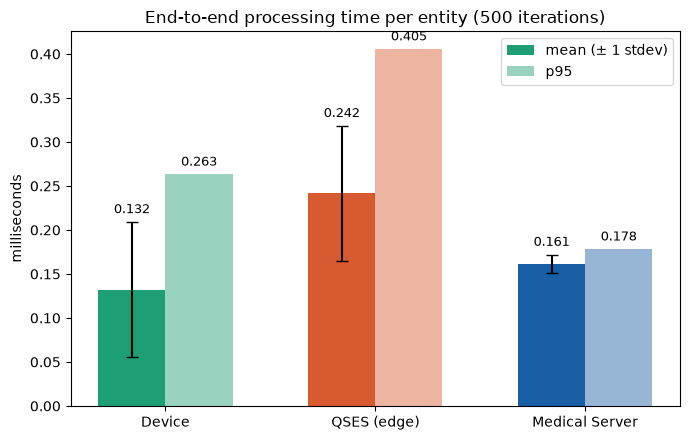

In [2]:
entities = ["device", "qses", "server"]
labels = ["Device", "QSES (edge)", "Medical Server"]
colors = [COLOR_DEVICE, COLOR_QSES, COLOR_SERVER]

means = [data["end_to_end"][e]["stats"]["mean"] for e in entities]
stdevs = [data["end_to_end"][e]["stats"]["stdev"] for e in entities]
p95s = [data["end_to_end"][e]["stats"]["p95"] for e in entities]

x = [0, 1, 2]
w = 0.32

fig, ax = plt.subplots(figsize=(7, 4.5))
bars_mean = ax.bar([i - w/2 for i in x], means, width=w, yerr=stdevs, capsize=4,
                    color=colors, label="mean (\u00b1 1 stdev)")
bars_p95 = ax.bar([i + w/2 for i in x], p95s, width=w, color=colors, alpha=0.45, label="p95")

for i, v in enumerate(means):
    ax.text(i - w/2, v + stdevs[i] + 0.01, f"{v:.3f}", ha="center", fontsize=9)
for i, v in enumerate(p95s):
    ax.text(i + w/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("milliseconds")
ax.set_title(f"End-to-end processing time per entity ({data['iterations']} iterations)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Client time vs. the paper's reported figure

The paper reports **1.87 ms** client-side computation (Dilithium2 signing
only, on their Google Colab / Intel Xeon setup). Our client does the same
operation \u2014 sign only, no encryption or KEM \u2014 but on different hardware, so
the absolute numbers aren't directly comparable; this chart shows the ratio.

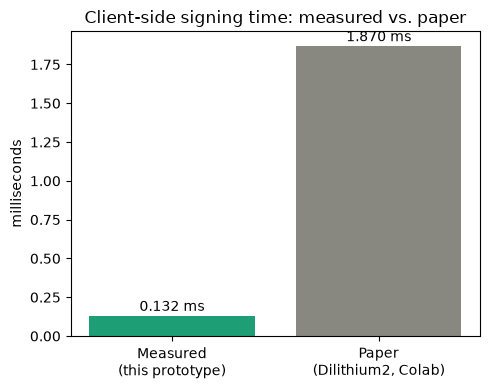

Measured is 0.07x the paper's figure (faster — different CPU, not a discrepancy in the protocol).


In [3]:
PAPER_CLIENT_MS = 1.87
measured = data["end_to_end"]["device"]["stats"]["mean"]
ratio = measured / PAPER_CLIENT_MS

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Measured\n(this prototype)", "Paper\n(Dilithium2, Colab)"],
               [measured, PAPER_CLIENT_MS],
               color=[COLOR_DEVICE, "#888780"])
for b, v in zip(bars, [measured, PAPER_CLIENT_MS]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.03, f"{v:.3f} ms", ha="center", fontsize=10)

ax.set_ylabel("milliseconds")
ax.set_title("Client-side signing time: measured vs. paper")
plt.tight_layout()
plt.show()

print(f"Measured is {ratio:.2f}x the paper's figure "
      f"({'faster' if ratio < 1 else 'slower'} \u2014 different CPU, not a discrepancy in the protocol).")

## 3. Per-primitive breakdown

The raw cost of each individual cryptographic operation, isolated from
packet parsing and Python object overhead. Log scale on the x-axis, because
ML-DSA-44 signing is roughly 50\u00d7 slower than a single AES-GCM call on this
data \u2014 a linear scale would flatten everything else to invisible slivers.
Bars are colored by which entity performs that operation.

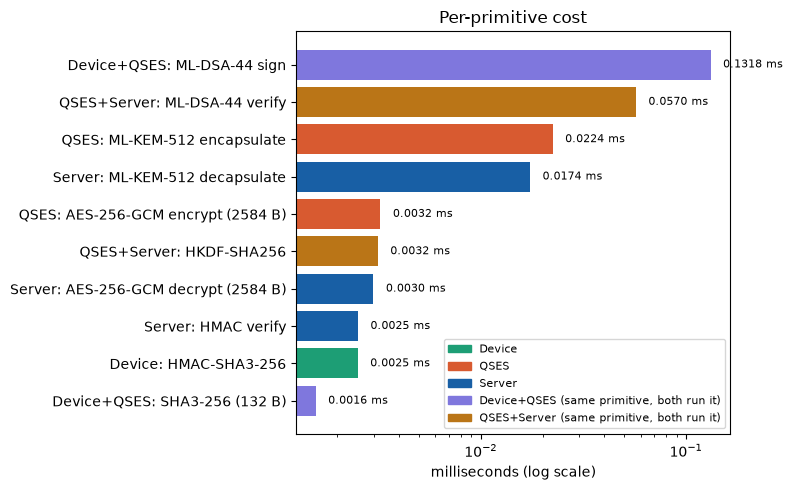

In [4]:
def color_for(label):
    prefix = label.split(":")[0]
    return {
        "Device": COLOR_DEVICE,
        "QSES": COLOR_QSES,
        "Server": COLOR_SERVER,
        "Device+QSES": COLOR_SHARED,
        "QSES+Server": COLOR_QSES_SERVER,
    }.get(prefix, "#888780")

ops = sorted(data["operations"].items(), key=lambda kv: kv[1]["mean"])
op_labels = [k for k, _ in ops]
op_means = [v["mean"] for _, v in ops]
op_colors = [color_for(k) for k in op_labels]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(op_labels, op_means, color=op_colors)
ax.set_xscale("log")
ax.set_xlabel("milliseconds (log scale)")
ax.set_title("Per-primitive cost")

for i, v in enumerate(op_means):
    ax.text(v * 1.15, i, f"{v:.4f} ms", va="center", fontsize=8)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=COLOR_DEVICE, label="Device"),
    plt.Rectangle((0, 0), 1, 1, color=COLOR_QSES, label="QSES"),
    plt.Rectangle((0, 0), 1, 1, color=COLOR_SERVER, label="Server"),
    plt.Rectangle((0, 0), 1, 1, color=COLOR_SHARED, label="Device+QSES (same primitive, both run it)"),
    plt.Rectangle((0, 0), 1, 1, color=COLOR_QSES_SERVER, label="QSES+Server (same primitive, both run it)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

> **Why these numbers don't sum exactly to the end-to-end chart above:**
> the end-to-end measurement also includes packet construction and parsing,
> metadata serialization, Python object/dataclass overhead, and (for QSES
> and the server) the registry lookups and sequence/nonce checks \u2014 none of
> which are isolated primitives on their own. The per-primitive chart tells
> you *where the heavy cost concentrates*; the end-to-end chart tells you
> *what a caller actually pays*. Both are true at once.

## 4. Resource usage per phase

CPU% and resident memory (RSS) captured during each entity's phase of the
benchmark. All three entities share one Python process in this benchmark, so
treat RSS as roughly cumulative (each later phase's RSS includes everything
allocated before it) rather than three fully isolated measurements.

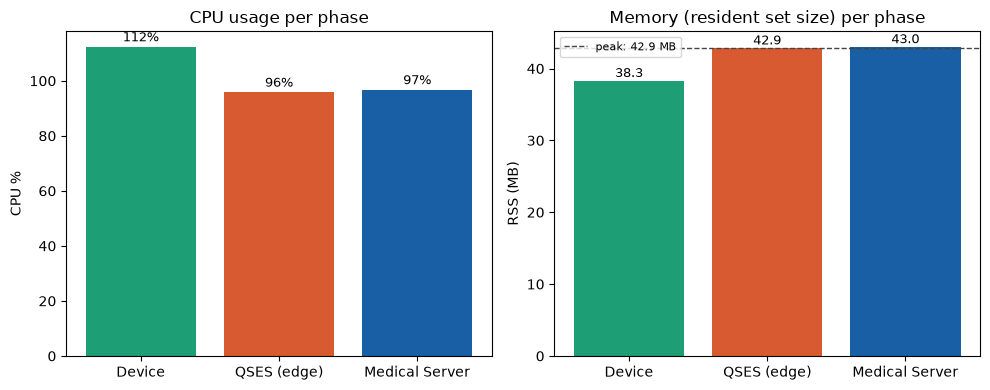

In [5]:
cpu_vals = [data["end_to_end"][e]["cpu_pct"] for e in entities]
rss_vals = [data["end_to_end"][e]["rss_mb"] for e in entities]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels, cpu_vals, color=colors)
axes[0].set_ylabel("CPU %")
axes[0].set_title("CPU usage per phase")
for i, v in enumerate(cpu_vals):
    axes[0].text(i, v + 2, f"{v:.0f}%", ha="center", fontsize=9)

axes[1].bar(labels, rss_vals, color=colors)
axes[1].set_ylabel("RSS (MB)")
axes[1].set_title("Memory (resident set size) per phase")
axes[1].axhline(data["peak_rss_mb"], color="#444441", linestyle="--", linewidth=1, label=f"peak: {data['peak_rss_mb']:.1f} MB")
axes[1].legend(fontsize=8)
for i, v in enumerate(rss_vals):
    axes[1].text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 5. Communication overhead

How the 8,416-byte total wire cost splits between the two hops. Phase 1
(client \u2192 edge) is dominated by the Dilithium2 signature; Phase 2
(edge \u2192 server) adds a second signature plus the KEM ciphertext and the
encrypted Phase-1 payload riding inside it.

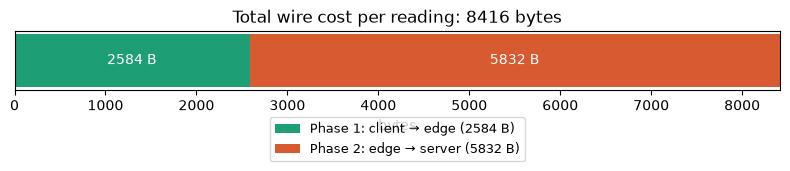

In [6]:
p1 = data["packet_sizes"]["phase1"]
p2 = data["packet_sizes"]["phase2"]
total = data["packet_sizes"]["total"]

fig, ax = plt.subplots(figsize=(8, 2.2))
ax.barh([0], [p1], color=COLOR_DEVICE, label=f"Phase 1: client \u2192 edge ({p1} B)")
ax.barh([0], [p2], left=[p1], color=COLOR_QSES, label=f"Phase 2: edge \u2192 server ({p2} B)")

ax.text(p1 / 2, 0, f"{p1} B", ha="center", va="center", color="white", fontsize=10)
ax.text(p1 + p2 / 2, 0, f"{p2} B", ha="center", va="center", color="white", fontsize=10)

ax.set_xlim(0, total)
ax.set_yticks([])
ax.set_xlabel("bytes")
ax.set_title(f"Total wire cost per reading: {total} bytes")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=1, fontsize=9)
plt.tight_layout()
plt.show()

## Summary

In [7]:
print(f"Iterations:              {data['iterations']}")
print(f"Device mean (sign only): {data['end_to_end']['device']['stats']['mean']:.3f} ms  "
      f"(paper: {PAPER_CLIENT_MS} ms, {measured / PAPER_CLIENT_MS:.2f}x)")
print(f"QSES mean:               {data['end_to_end']['qses']['stats']['mean']:.3f} ms")
print(f"Server mean:             {data['end_to_end']['server']['stats']['mean']:.3f} ms")
print(f"Phase 1 size:            {p1} bytes  (paper: 2584)")
print(f"Phase 2 size:            {p2} bytes  (paper: 5832)")
print(f"Total overhead:          {total} bytes  (paper: 8416)")
print(f"Peak RSS:                {data['peak_rss_mb']:.1f} MB")

Iterations:              500
Device mean (sign only): 0.132 ms  (paper: 1.87 ms, 0.07x)
QSES mean:               0.242 ms
Server mean:             0.161 ms
Phase 1 size:            2584 bytes  (paper: 2584)
Phase 2 size:            5832 bytes  (paper: 5832)
Total overhead:          8416 bytes  (paper: 8416)
Peak RSS:                42.9 MB
